In [1]:
!pip install aubio

In [ ]:
import wave
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import aubio

In [3]:
data_dir = "data/"
filename = "self.wav"
data_file= os.path.join(data_dir, filename)

In [4]:
audio_file = wave.open(data_file, "r")


In [5]:
frames = audio_file.readframes(-1)
rate = audio_file.getframerate()

In [6]:
audio_file.close()

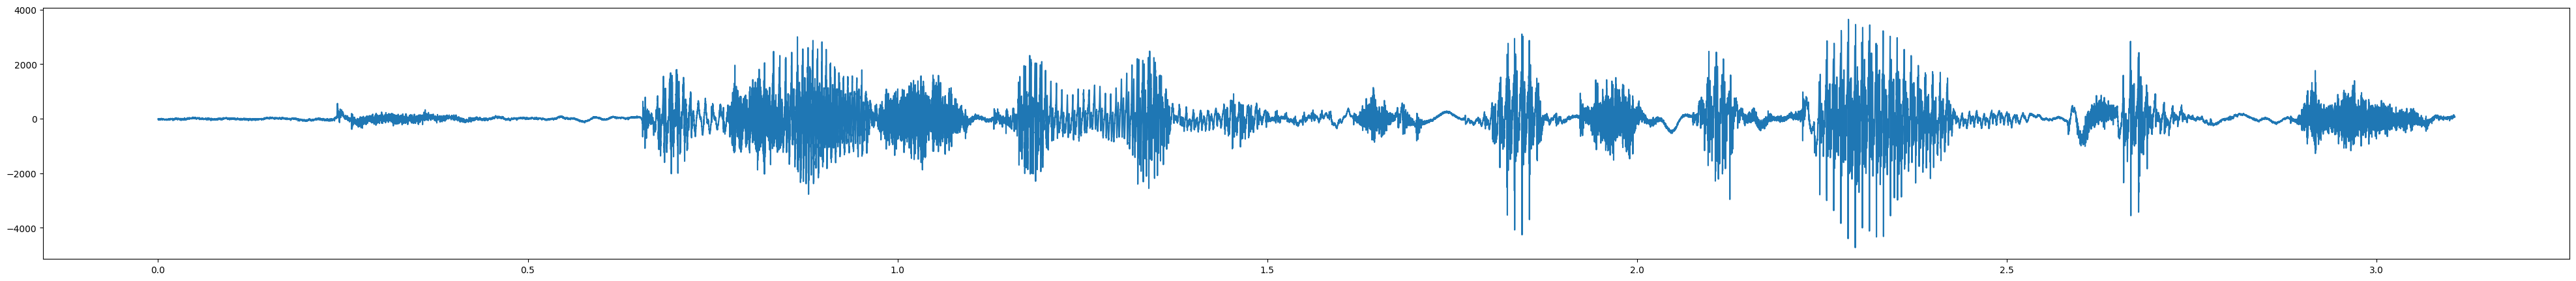

In [7]:
signal = np.frombuffer(frames, np.int16)

sec = np.linspace(0, len(signal)/rate, num = len(signal))
plt.figure(figsize=(50, 5))
plt.plot(sec, signal)
plt.show()

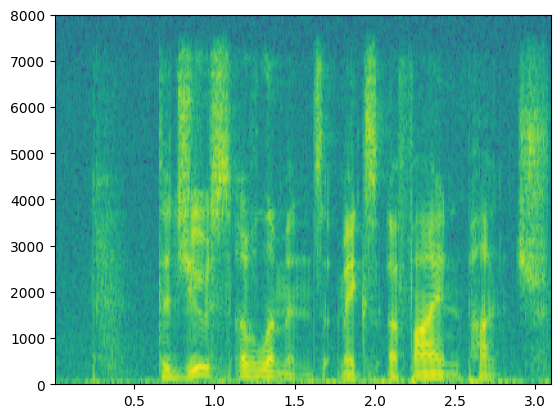

In [8]:
plt.specgram(signal,Fs=rate)
plt.show()

In [9]:
def log_square_magnitude(complex_num_array):
    mag = []
    for cn in complex_num_array:
        mag.append(10*np.log10((cn.real**2 + cn.imag**2)**.5))
    return mag

In [10]:
window_size_ms = 25
window_shift_ms = 10
frames_per_window =int( rate * window_size_ms / 1000)
frames_per_shift = int( rate * window_shift_ms / 1000)

pitch_detection = aubio.pitch("yin", frames_per_window, frames_per_shift,  rate)

windowed_fft = []
windowed_energy  = []
pitchs = []
i = 0
while i + frames_per_window < len(signal):
    window = signal[i: i+frames_per_window]
    window = window * np.hanning(frames_per_window)  
    windowed_energy.append(np.sum(window**2))
    fft = np.fft.fft(window)
    mags = log_square_magnitude(fft[:frames_per_window//2])
    windowed_fft.append(mags)
    i += int(frames_per_shift)
i=0
while i + frames_per_shift < len(signal):
      shift = signal[i: i+frames_per_shift]
      pitchs.append(pitch_detection(shift.astype(np.float32) / 32768.0)[0])
      i += int(frames_per_shift)
spec = np.array(windowed_fft).T
energy = np.array(windowed_energy)
pitchs = np.array(pitchs[:-1])
alpha = spec/spec.max()

In [11]:
freq, windows = alpha.shape

spectrogram = np.zeros((freq, windows, 4))

# Set color (blue)
spectrogram[...,1, 2,3] = 1.0

# Set alpha from magnitude
spectrogram[..., 3] = alpha

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06874633140851852..1.0].


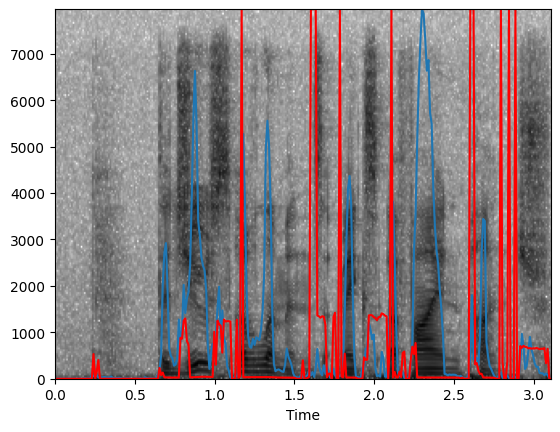

In [12]:
freqs = [i * rate / frames_per_window for i in range(len(spec))]
sec = np.linspace(0, len(signal)/rate, num = len(windowed_energy))
plt.imshow(spectrogram, 
           origin ='lower', 
           aspect ='auto',
           extent = [sec[0], sec[-1], freqs[0], freqs[-1]])
plt.xlabel("Time")
energy = energy/energy.max()
energy = energy * freqs[-1]
plt.plot(sec, energy)
pitchs = pitchs/pitchs.max()
pitchs = pitchs * freqs[-1]

plt.plot(sec, pitchs, color="red")
plt.show()